# 交叉熵损失函数（Cross-Entropy Loss）
- 是深度学习中最基础、最核心的损失函数之一，广泛应用于二分类、多分类以及自然语言处理（如大语言模型的SFT阶段）。

要真正理解它，我们不能只背公式，而**需要从信息论的直觉出发**，再过渡到机器学习的数学推导。下面我为你进行全景式的详细拆解：

## 信息论视角：为什么叫“交叉熵”？
在信息论中，衡量信息量的单位是“比特（bit）”或“纳特（nat）”。
- 熵（Entropy, H(P) ）：**衡量一个真实分布 P 的“混乱程度”或“不确定性”**。
- 交叉熵（Cross-Entropy, H(P,Q) ）：假设真实分布是 P ，但我们用另一个分布 Q （比如我们训练的模型）来对数据进行编码。
  - <font color='red'>交叉熵衡量的是：用模型 Q 去编码真实数据 P 时，平均需要花费多少信息量（或代价）。</font>

### 核心直觉：
- **如果模型 Q 完美预测了真实数据 P** ，<font color='red'>那么交叉熵就等于 P 自身的熵，这是理论上的最小值。</font>
- **如果模型 Q 预测错了，或者对正确答案给出的概率很低**，<font color='red'>那么为了弥补这个误差，我们需要花费更多的信息量，交叉熵的值就会急剧变大。</font>

## 数学公式推导

In [1]:
from IPython.display import Image

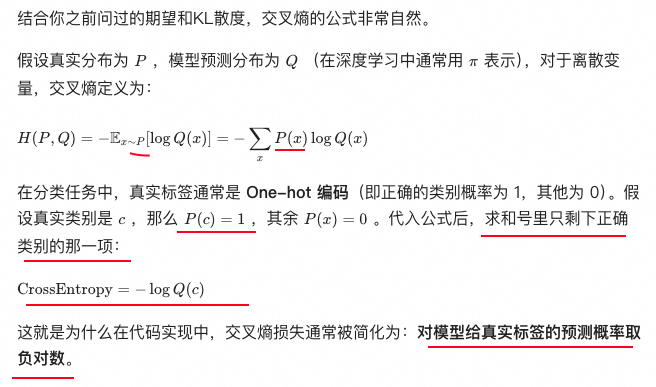

In [2]:
Image(filename='./Image/cel.png')

## 与 KL 散度的关系（温故知新）
根据吉布斯不等式（Gibbs' Inequality），交叉熵可以拆解为：
$H(P,Q)=H(P)+D_{KL}(P∥Q)$
- H(P) 是真实数据的熵（常数）。
- $D_{KL}(P∥Q)$ 是前向KL散度（永远 ≥0 ）。

### 结论：
因为 H(P) 是常数，最小化交叉熵 ⟺ 最小化 KL 散度。
- <font color='red'>这就解释了为什么在 SFT 训练中，我们虽然只写了交叉熵的代码，但本质上是在拉近模型分布和真实数据分布的距离</font>

##  为什么交叉熵比均方误差（MSE）更适合分类？
在早期的神经网络中，人们曾尝试用 MSE 来做分类，但效果极差。
**交叉熵胜出是因为它的梯度特性：**

假设使用 Sigmoid/Softmax 激活函数，我们来看损失对模型输出 z 的梯度：
- MSE 的梯度：
  - 包含 Sigmoid 的导数项 σ(z)(1−σ(z)) 。当模型犯下严重错误时（比如真实是1，模型预测接近0），Sigmoid 进入饱和区，导数趋近于 0。这会导致梯度消失，模型学不动了。
- 交叉熵的梯度：
  - <font color='red'>求导后，Sigmoid 的导数项被 \frac{1}{σ(z)}完美抵消了！最终的梯度变成了极其简单的形式： (预测值−真实值)</font>

### 核心优势：
- **模型错得越离谱，初始梯度越大，学习速度越快；模型预测越准，梯度越小，收敛越平稳。**
- 这种“**知错能改，大错大改**”的特性<font color='red'>是交叉熵成为分类任务霸主的根本原因</font>

##  在代码与工程中的落地
在 PyTorch 中，我们通常不手动写 -log(Q(c))，而是直接使用高度优化的底层算子：
- nn.CrossEntropyLoss()：
  - **这是最常用的多分类损失**。<font color='red'>注意，它的输入是模型输出的 Logits（未经过 Softmax 的原始分数），内部会自动帮你做 Softmax 再算交叉熵。</font>
  - 这种合并计算不仅代码简洁，**还能避免单独计算 Softmax 时可能出现的数值溢出（Underflow/Overflow）问题。**
- nn.BCEWithLogitsLoss()：
  - 用于二分类或多标签分类，内部合并了 Sigmoid 和交叉熵。

# 交叉熵的梯度特性

- 交叉熵损失函数之所以能统治分类和自然语言处理领域，其核心秘密就在于它极其优美的梯度特性。
- 正如我们之前提到的，相比于均方误差（MSE），交叉熵能够完美解决深度学习中的梯度消失（Vanishing Gradient）问题。

下面我将从**数学推导**和**直觉**两个层面，为你详细拆解它的梯度特性。

## 核心结论：极其简洁的梯度形式


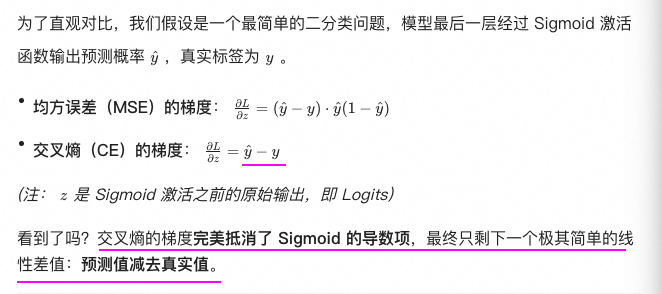

In [7]:
Image(filename='./Image/c1.png')

##   数学推导：它是如何“抵消”的？

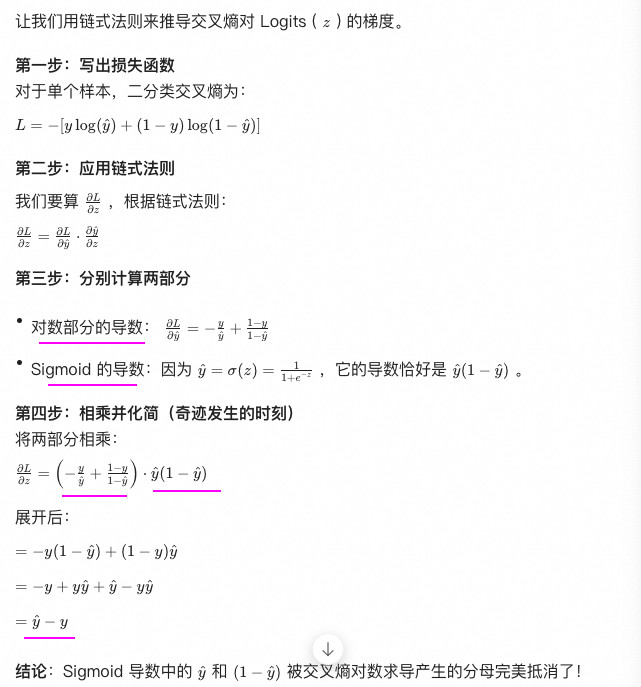

In [8]:
Image(filename='./Image/c2.png')

## 对比 MSE：为什么 MSE 会“学不动”？

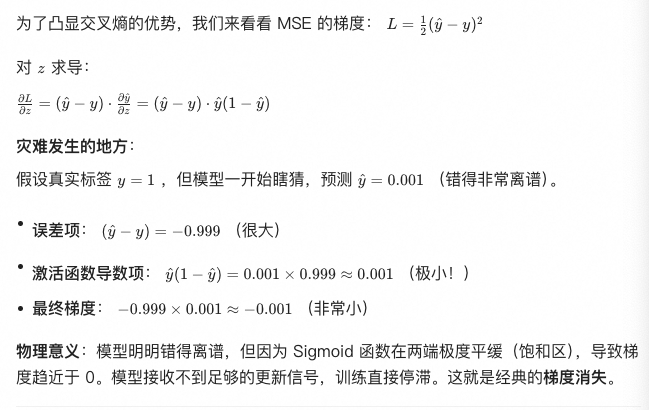

In [5]:
Image(filename='./Image/c3.png')

## 交叉熵梯度的物理意义

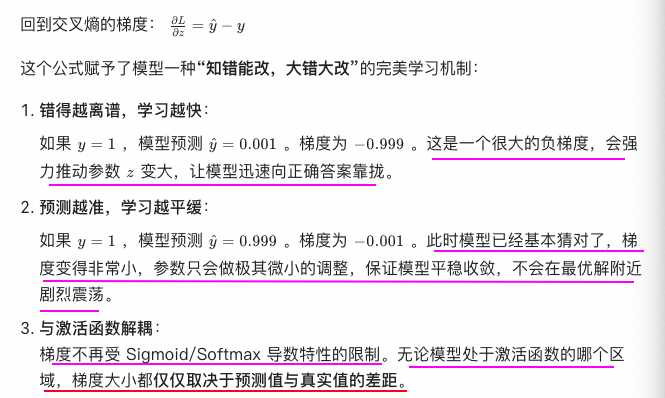

In [9]:
Image(filename='./Image/c4.png')

## 总结
- 交叉熵的梯度特性，本质上是信息论的惩罚机制与微积分链式法则的完美结合。
- <font color='red'>它通过负对数函数的导数，精准地“吃掉”了非线性激活函数带来的梯度衰减，确保了误差信号能够无损地传回模型参数，这也是它成为所有现代大语言模型（如 SFT 阶段）标配损失函数的根本原因。</font>